# 02 - EDA si cleanup usor

Scop:
- citim datasetul din HDFS;
- eliminam coloane slab utile pentru modelare;
- tratam valori lipsa;
- calculam statistici descriptive;
- identificam outlieri pentru intarzieri;
- cream cateva grafice simple;
- salvam dataset curatat tot ca CSV in HDFS.

Nu folosim biblioteci externe peste Dockerfile: PySpark, pandas, matplotlib.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel

spark = (
    SparkSession.builder
    .appName("FlightsProject")
    .master("spark://master:7077")
    .config("spark.executor.memory", "1g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "2")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 15:25:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.8
Master: spark://master:7077


In [2]:
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.width", 140)

def show_small(sdf, n=20):
    return sdf.limit(n).toPandas()


In [3]:
HDFS_RAW_CSV = "hdfs://master:9000/flights/raw/flights.csv"

flights = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(HDFS_RAW_CSV)
    .repartition(4)
)

print("Randuri initiale:", flights.count())
flights.printSchema()

preview_cols = [c for c in [
    "year", "month", "day", "carrier", "origin", "dest",
    "dep_delay", "arr_delay", "air_time", "distance"
] if c in flights.columns]

show_small(flights.select(*preview_cols), 10)


Randuri initiale: 336776
root
 |-- id: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- day: integer (nullable = true)
 |-- dep_time: double (nullable = true)
 |-- sched_dep_time: integer (nullable = true)
 |-- dep_delay: double (nullable = true)
 |-- arr_time: double (nullable = true)
 |-- sched_arr_time: integer (nullable = true)
 |-- arr_delay: double (nullable = true)
 |-- carrier: string (nullable = true)
 |-- flight: integer (nullable = true)
 |-- tailnum: string (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- air_time: double (nullable = true)
 |-- distance: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- minute: integer (nullable = true)
 |-- time_hour: timestamp (nullable = true)
 |-- name: string (nullable = true)



,year,month,day,carrier,origin,dest,dep_delay,arr_delay,air_time,distance
0,2013,10,27,FL,LGA,ATL,7.0,-15.0,105.0,762
1,2013,10,2,B6,JFK,SJU,-4.0,-11.0,197.0,1598
2,2013,12,19,MQ,LGA,RDU,-2.0,0.0,74.0,431
3,2013,12,8,B6,JFK,PWM,276.0,267.0,43.0,273
4,2013,2,20,EV,EWR,GSO,0.0,4.0,73.0,445
5,2013,4,1,DL,JFK,MCO,-6.0,-14.0,141.0,944
6,2013,1,16,EV,EWR,STL,132.0,149.0,159.0,872
7,2013,10,1,UA,EWR,TPA,8.0,-18.0,127.0,997
8,2013,4,3,EV,EWR,BNA,-10.0,-5.0,136.0,748
9,2013,12,2,AA,JFK,LAX,73.0,73.0,343.0,2475


In [4]:
# Selectie coloane utile. Pastram id daca exista, dar nu il folosim in ML.
wanted_cols = [
    "id", "year", "month", "day", "dep_time", "sched_dep_time", "dep_delay",
    "arr_time", "sched_arr_time", "arr_delay", "carrier", "flight", "tailnum",
    "origin", "dest", "air_time", "distance", "hour", "minute", "time_hour", "name"
]
existing_cols = [c for c in wanted_cols if c in flights.columns]
flights = flights.select(*existing_cols)

# Curatare usoara:
# - eliminam randurile fara tinta arr_delay;
# - eliminam randurile fara coloane esentiale;
# - pastram numai valori operationale valide pentru timp, distanta si durata.
required = ["arr_delay", "dep_delay", "air_time", "distance", "carrier", "origin", "dest", "month", "day", "hour"]
required = [c for c in required if c in flights.columns]

clean = flights.dropna(subset=required)

numeric_fill_zero = [c for c in ["minute"] if c in clean.columns]
clean = clean.fillna(0, subset=numeric_fill_zero)

# Coloane derivate simple pentru EDA, SQL si ML.
clean = (
    clean
    .filter((F.col("air_time") > 0) & (F.col("distance") > 0))
    .withColumn("is_dep_delayed", F.when(F.col("dep_delay") > 15, 1).otherwise(0))
    .withColumn("is_arr_delayed", F.when(F.col("arr_delay") > 15, 1).otherwise(0))
    .withColumn("route", F.concat_ws("-", F.col("origin"), F.col("dest")))
    .withColumn("speed_mph", F.when(F.col("air_time") > 0, F.col("distance") / (F.col("air_time") / 60.0)).otherwise(None))
    .withColumn("sched_dep_minutes", (F.floor(F.col("sched_dep_time") / 100) * 60 + (F.col("sched_dep_time") % 100)).cast("int"))
    .withColumn("sched_arr_minutes", (F.floor(F.col("sched_arr_time") / 100) * 60 + (F.col("sched_arr_time") % 100)).cast("int"))
    .withColumn("flight_date", F.to_date(F.concat_ws("-", F.col("year"), F.col("month"), F.col("day"))))
    .withColumn("day_of_week", F.dayofweek(F.col("flight_date")))
    .withColumn("is_weekend", F.when(F.col("day_of_week").isin(1, 7), 1).otherwise(0))
)

clean = clean.persist(StorageLevel.MEMORY_AND_DISK)

print("Randuri dupa cleanup:", clean.count())
show_small(clean.select(
    "year", "month", "day", "day_of_week", "is_weekend",
    "carrier", "origin", "dest", "route",
    "dep_delay", "arr_delay", "air_time", "distance", "speed_mph"
), 10)


26/04/27 15:25:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

Randuri dupa cleanup: 327346


,year,month,day,day_of_week,is_weekend,carrier,origin,dest,route,dep_delay,arr_delay,air_time,distance,speed_mph
0,2013,9,30,2,0,EV,EWR,IND,EWR-IND,12.0,-4.0,90.0,645,430.000000
1,2013,7,31,4,0,EV,EWR,OKC,EWR-OKC,3.0,-7.0,180.0,1325,441.666667
2,2013,9,30,2,0,B6,JFK,LAS,JFK-LAS,-3.0,-23.0,281.0,2248,480.000000
3,2013,6,4,3,0,DL,LGA,MSP,LGA-MSP,-6.0,11.0,154.0,1020,397.402597
4,2013,9,22,1,1,AA,EWR,DFW,EWR-DFW,-2.0,-21.0,179.0,1372,459.888268
5,2013,8,6,3,0,UA,EWR,LAX,EWR-LAX,33.0,24.0,322.0,2454,457.267081
6,2013,9,5,5,0,UA,EWR,SFO,EWR-SFO,5.0,-17.0,329.0,2565,467.781155
7,2013,9,11,4,0,EV,LGA,RIC,LGA-RIC,-4.0,-34.0,51.0,292,343.529412
8,2013,9,10,3,0,MQ,LGA,MSP,LGA-MSP,-3.0,-19.0,141.0,1020,434.042553
9,2013,4,22,2,0,MQ,LGA,CMH,LGA-CMH,107.0,142.0,77.0,479,373.246753


In [6]:
# Statistici descriptive in format lung, ca sa nu se suprapuna in Jupyter.
num_cols = [c for c in ["dep_delay", "arr_delay", "air_time", "distance", "speed_mph"] if c in clean.columns]

stats_rows = []

for c in num_cols:
    x = F.col(c).cast("double")

    r = clean.select(
        F.lit(c).alias("column"),
        F.round(F.min(x), 2).cast("double").alias("min"),
        F.round(F.max(x), 2).cast("double").alias("max"),
        F.round(F.avg(x), 2).cast("double").alias("avg"),
        F.round(F.sum(x), 2).cast("double").alias("sum"),
        F.round(F.stddev(x), 2).cast("double").alias("stddev"),
        F.round(F.variance(x), 2).cast("double").alias("variance"),
        F.round(F.skewness(x), 2).cast("double").alias("skewness"),
        F.round(F.kurtosis(x), 2).cast("double").alias("kurtosis")
    ).first()

    stats_rows.append(r)

stats = spark.createDataFrame(stats_rows)
show_small(stats, 20)

,column,min,max,avg,sum,stddev,variance,skewness,kurtosis
0,dep_delay,-43.0,1301.00,12.56,4.109880e+06,40.07,1605.26,4.82,44.35
1,arr_delay,-86.0,1272.00,6.90,2.257174e+06,44.63,1992.13,3.72,29.23
2,air_time,20.0,695.00,150.69,4.932661e+07,93.69,8777.50,1.07,0.86
3,distance,80.0,4983.00,1048.37,3.431802e+08,735.91,541561.35,1.11,1.15
4,speed_mph,76.8,703.38,394.27,1.290639e+08,60.63,3676.36,-0.71,0.44


In [7]:
# Quantile si outlieri dupa metoda IQR pentru intarzieri.
outlier_rows = []
for c in ["arr_delay", "dep_delay"]:
    q0, q1, q2, q3, q90, q95, q99 = clean.approxQuantile(c, [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99], 0.01)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    out_count = clean.filter((F.col(c) < low) | (F.col(c) > high)).count()
    outlier_rows.append((c, q0, q1, q2, q3, q90, q95, q99, low, high, out_count))

outliers = spark.createDataFrame(
    outlier_rows,
    ["column", "min_q0", "q1_25", "median_q2", "q3_75", "q90", "q95", "q99", "iqr_low", "iqr_high", "outliers"]
)

show_small(outliers, 10)


,column,min_q0,q1_25,median_q2,q3_75,q90,q95,q99,iqr_low,iqr_high,outliers
0,arr_delay,-86.0,-17.0,-5.0,13.0,49.0,83.0,1272.0,-62.0,58.0,28968
1,dep_delay,-43.0,-5.0,-2.0,10.0,46.0,81.0,1301.0,-27.5,32.5,45803


In [8]:
# Agregari EDA pe categorii.
by_carrier = (
    clean.groupBy("carrier", "name")
    .agg(
        F.count("*").alias("flights"),
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay"),
        F.round(F.avg("arr_delay"), 2).alias("avg_arr_delay"),
        F.round(F.avg("distance"), 2).alias("avg_distance")
    )
    .orderBy(F.desc("flights"))
)

by_route = (
    clean.groupBy("route")
    .agg(
        F.count("*").alias("flights"),
        F.round(F.avg("arr_delay"), 2).alias("avg_arr_delay")
    )
    .orderBy(F.desc("flights"))
)

show_small(by_carrier, 20)


,carrier,name,flights,avg_dep_delay,avg_arr_delay,avg_distance
0,UA,United Air Lines Inc.,57782,12.02,3.56,1531.32
1,B6,JetBlue Airways,54049,12.97,9.46,1069.69
2,EV,ExpressJet Airlines Inc.,51108,19.84,15.80,562.87
3,DL,Delta Air Lines Inc.,47658,9.22,1.64,1237.98
4,AA,American Airlines Inc.,31947,8.57,0.36,1343.28
5,MQ,Envoy Air,25037,10.45,10.77,570.37
6,US,US Airways Inc.,19831,3.74,2.13,560.83
7,9E,Endeavor Air Inc.,17294,16.44,7.38,529.89
8,WN,Southwest Airlines Co.,12044,17.66,9.65,996.97
9,VX,Virgin America,5116,12.76,1.76,2499.43


In [9]:
show_small(by_route, 20)

,route,flights,avg_arr_delay
0,JFK-LAX,11159,-0.48
1,LGA-ATL,10041,11.32
2,LGA-ORD,8507,1.83
3,JFK-SFO,8109,2.88
4,LGA-CLT,5961,7.38
5,EWR-ORD,5828,9.00
6,JFK-BOS,5773,4.91
7,LGA-MIA,5702,-0.07
8,JFK-MCO,5429,5.30
9,EWR-BOS,5247,4.78


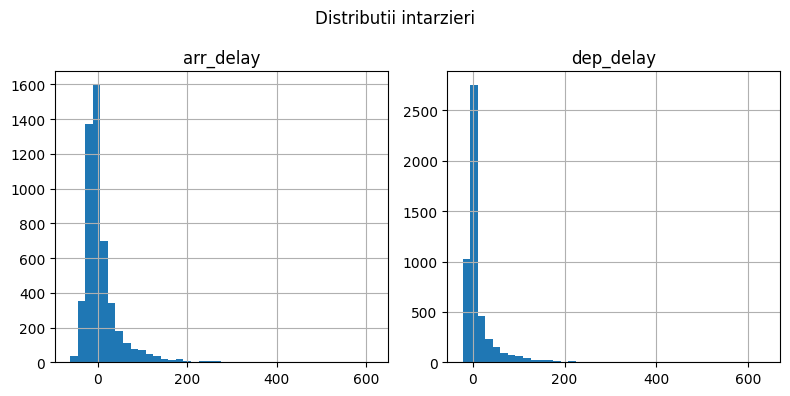

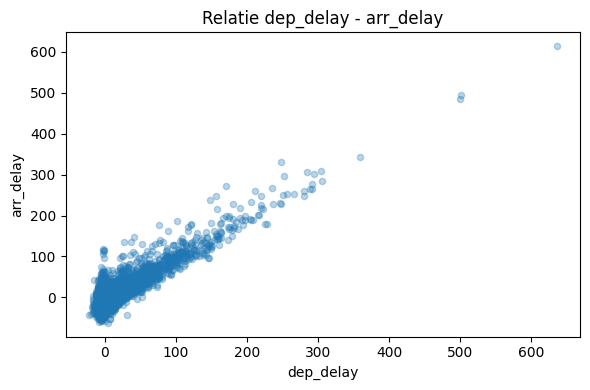

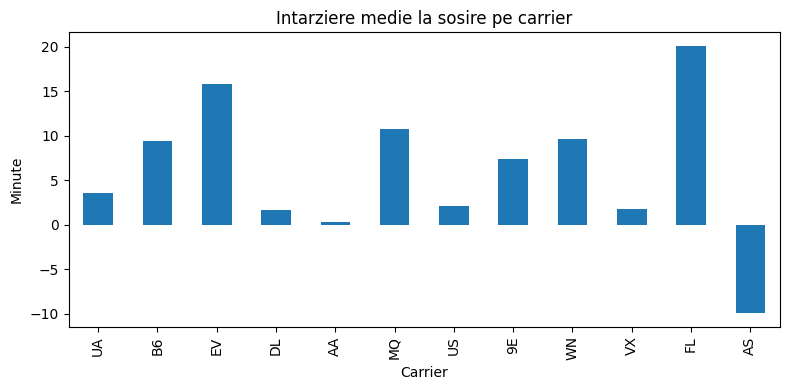

In [10]:
# Grafice simple pe sample mic ca sa nu incarcam driverul.
import matplotlib.pyplot as plt

sample_pdf = (
    clean.select("arr_delay", "dep_delay", "distance", "air_time", "carrier", "month")
    .sample(False, 0.05, seed=42)
    .limit(5000)
    .toPandas()
)

sample_pdf[["arr_delay", "dep_delay"]].hist(bins=40, figsize=(8, 4))
plt.suptitle("Distributii intarzieri")
plt.tight_layout()
plt.show()

sample_pdf.plot.scatter(x="dep_delay", y="arr_delay", alpha=0.3, figsize=(6, 4))
plt.title("Relatie dep_delay - arr_delay")
plt.tight_layout()
plt.show()

carrier_pdf = by_carrier.limit(12).toPandas()
carrier_pdf.plot.bar(x="carrier", y="avg_arr_delay", legend=False, figsize=(8, 4))
plt.title("Intarziere medie la sosire pe carrier")
plt.xlabel("Carrier")
plt.ylabel("Minute")
plt.tight_layout()
plt.show()


In [11]:
# Salvam datasetul curatat in HDFS ca CSV, nu Parquet.
# Coalesce(4) pastreaza fisiere multiple si evita blocarea driverului pe un singur fisier.
OUTPUT_PATH = "hdfs://master:9000/flights/clean"

(
    clean
    .coalesce(4)
    .write
    .mode("overwrite")
    .option("header", "true")
    .csv(OUTPUT_PATH)
)

print("Dataset curatat salvat in:", OUTPUT_PATH)


Dataset curatat salvat in: hdfs://master:9000/flights/clean


Interpretare:
- Intarzierile sunt asimetrice: multe zboruri au intarzieri mici sau negative, dar exista outlieri pozitivi mari.
- Quantilele arata unde se afla 25%, 50%, 75%, 90%, 95% si 99% din valori. De exemplu, q95 pentru `arr_delay` inseamna ca aproximativ 95% din zboruri au intarziere la sosire mai mica sau egala cu acea valoare.
- IQR = Q3 - Q1. Pragurile IQR sunt `Q1 - 1.5 * IQR` si `Q3 + 1.5 * IQR`. Valorile in afara lor sunt outlieri.
- `dep_delay` este corelat cu `arr_delay`, deoarece o plecare intarziata se transmite frecvent la sosire.
- Agregarile pe carrier si ruta arata diferente operationale intre companii si trasee.
- Cleanup-ul ramane simplu: eliminare valori lipsa esentiale, pastrare valori operationale valide, coloane derivate si salvare CSV.


In [12]:
clean.unpersist()
spark.stop()
